<a href="https://colab.research.google.com/github/athirasureshev-lab/Accidental-Drug-Related-Death-Analysis/blob/main/Accidental_Drug_Related_Death_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="text-align:center; color:#0d3b66; font-size:40px;">
📊 Accidental Drug-Related Death Analysis
</h1>

<h3 style="text-align:center; color:#555;">
A Data-Driven Exploratory Study Using Python
</h3>

<br>

<h2 style="color:#0d3b66;">🎯 Aim of the Project</h2>

<p style="font-size:16px;">
The aim of this project is to analyze accidental drug-related deaths to identify key patterns, trends, and risk factors across different demographic groups and time periods.
</p>

<ul style="font-size:16px;">
<li>Understand distribution across <b>age, sex, and race</b></li>
<li>Identify the most common <b>drug types</b> involved</li>
<li>Analyze <b>yearly and quarterly trends</b></li>
<li>Explore relationships between different drugs</li>
<li>Generate insights for <b>data-driven decision making</b></li>
</ul>

# DATA LOADING AND INITIAL OVERVIEW

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Accidental_Drug_Related_Death.xlsx to Accidental_Drug_Related_Death.xlsx


In [5]:
import pandas as pd

df = pd.read_excel("Accidental_Drug_Related_Death.xlsx")

df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date of death                  1546 non-null   datetime64[ns]
 1   Age                            1546 non-null   int64         
 2   Sex                            1545 non-null   object        
 3   Race                           1528 non-null   object        
 4   Residence City                 1447 non-null   object        
 5   Residence County               1438 non-null   object        
 6   Residence State                1443 non-null   object        
 7   Injury City                    1515 non-null   object        
 8   Injury County                  1487 non-null   object        
 9   Injury State                   1468 non-null   object        
 10  Injury Place                   1426 non-null   object        
 11  Description of In

,Date of death,Age
count,1546,1546.000000
mean,2023-04-25 08:01:33.143596544,47.911384
min,2022-01-01 00:00:00,16.000000
25%,2022-08-03 00:00:00,37.000000
50%,2023-04-01 12:00:00,49.000000
75%,2024-01-02 00:00:00,58.000000
max,2024-12-12 00:00:00,78.000000
std,NaN,12.681022



## Number of Rows and Columns

In [ ]:
df.shape

(1546, 37)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date_of_death                 1546 non-null   datetime64[ns]
 1   Age                           1546 non-null   int64         
 2   Sex                           1545 non-null   object        
 3   Race                          1528 non-null   object        
 4   Residence_City                1447 non-null   object        
 5   Residence_County              1438 non-null   object        
 6   Residence_State               1443 non-null   object        
 7   Injury_City                   1515 non-null   object        
 8   Injury_County                 1487 non-null   object        
 9   Injury_State                  1468 non-null   object        
 10  Injury_Place                  1426 non-null   object        
 11  Description_of_Injury         

Initial Observations

In [6]:
df.head()

,Date of death,Age,Sex,Race,Residence City,Residence County,Residence State,Injury City,Injury County,Injury State,...,Amphet,Tramad,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid
0,2023-02-01,65,Male,White,BRIDGEPORT,FAIRFIELD,CT,BRIDGEPORT,FAIRFIELD,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
1,2023-04-02,34,Male,White,NaN,NaN,NaN,NEW HAVEN,NEW HAVEN,CT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
2,2022-01-03,24,Male,White,HARTFORD,HARTFORD,CT,HARTFORD,HARTFORD,CT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
3,2023-06-03,77,Male,White,BRISTOL,HARTFORD,CT,BRISTOL,HARTFORD,CT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
4,2023-06-07,53,Male,White,NEW HAVEN,NEW HAVEN,CT,NEW HAVEN,NEW HAVEN,CT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y


In [ ]:
df.describe()

,Date_of_death,Age
count,1546,1546.000000
mean,2023-04-25 08:01:33.143596544,47.911384
min,2022-01-01 00:00:00,16.000000
25%,2022-08-03 00:00:00,37.000000
50%,2023-04-01 12:00:00,49.000000
75%,2024-01-02 00:00:00,58.000000
max,2024-12-12 00:00:00,78.000000
std,NaN,12.681022


# DATA PRE-PROCESSING

## Handling Missing Values

In [ ]:
df[drug_columns].isnull().sum()

,0
Heroin,0
Cocaine,0
Fentanyl,0
Methadone,0


In [ ]:
df[drug_columns].head()

,Heroin,Cocaine,Fentanyl,Methadone
0,0,Cocaine,Fentanyl,0
1,0,Cocaine,Fentanyl,0
2,0,0,Fentanyl,0
3,0,0,Fentanyl,0
4,0,0,Fentanyl,0


In [ ]:
print("Missing values before:")
print(df[drug_columns].isnull().sum())

df[drug_columns] = df[drug_columns].fillna(0)

print("\nMissing values after:")
print(df[drug_columns].isnull().sum())

Missing values before:
Heroin       0
Cocaine      0
Fentanyl     0
Methadone    0
dtype: int64

Missing values after:
Heroin       0
Cocaine      0
Fentanyl     0
Methadone    0
dtype: int64


## Replace missing values in drug column

In [ ]:
drug_columns = ['Heroin','Cocaine','Fentanyl','Methadone','Any_Opioid']

df[drug_columns] = df[drug_columns].fillna(0)

## Remove Duplicate Records

In [ ]:
# Check number of duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Confirm removal
print("Rows after removing duplicates:", df.shape)

Duplicate rows: 0
Rows after removing duplicates: (1546, 37)


## Correcting Data Types

Convert date column:

In [ ]:
print(df.columns)

Index(['Date_of_death', 'Age', 'Sex', 'Race', 'Residence_City',
       'Residence_County', 'Residence_State', 'Injury_City', 'Injury_County',
       'Injury_State', 'Injury_Place', 'Description_of_Injury', 'Location',
       'Location_if_Other', 'Cause_of_Death', 'Manner_of_Death',
       'Other_Significant_Conditions', 'Heroin', 'Cocaine', 'Fentanyl',
       'Fentanyl_Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol',
       'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Amphet', 'Tramad',
       'Hydromorphone', 'Morphine_(Not_Heroin)', 'Xylazine', 'Gabapentin',
       'Opiate_NOS', 'Heroin/Morph/Codeine', 'Other_Opioid', 'Any_Opioid'],
      dtype='object')


In [ ]:
print(df.columns.tolist())

['Date_of_death', 'Age', 'Sex', 'Race', 'Residence_City', 'Residence_County', 'Residence_State', 'Injury_City', 'Injury_County', 'Injury_State', 'Injury_Place', 'Description_of_Injury', 'Location', 'Location_if_Other', 'Cause_of_Death', 'Manner_of_Death', 'Other_Significant_Conditions', 'Heroin', 'Cocaine', 'Fentanyl', 'Fentanyl_Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol', 'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Amphet', 'Tramad', 'Hydromorphone', 'Morphine_(Not_Heroin)', 'Xylazine', 'Gabapentin', 'Opiate_NOS', 'Heroin/Morph/Codeine', 'Other_Opioid', 'Any_Opioid']


In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
print(df.columns)

Index(['Date_of_death', 'Age', 'Sex', 'Race', 'Residence_City',
       'Residence_County', 'Residence_State', 'Injury_City', 'Injury_County',
       'Injury_State', 'Injury_Place', 'Description_of_Injury', 'Location',
       'Location_if_Other', 'Cause_of_Death', 'Manner_of_Death',
       'Other_Significant_Conditions', 'Heroin', 'Cocaine', 'Fentanyl',
       'Fentanyl_Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol',
       'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Amphet', 'Tramad',
       'Hydromorphone', 'Morphine_(Not_Heroin)', 'Xylazine', 'Gabapentin',
       'Opiate_NOS', 'Heroin/Morph/Codeine', 'Other_Opioid', 'Any_Opioid'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

print(df.columns)

if 'Date_of_Death' in df.columns:
    df['Date_of_Death'] = pd.to_datetime(df['Date_of_Death'])
elif 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
elif 'DateofDeath' in df.columns:
    df['DateofDeath'] = pd.to_datetime(df['DateofDeath'])

print("Date column converted successfully")

Index(['Date_of_death', 'Age', 'Sex', 'Race', 'Residence_City',
       'Residence_County', 'Residence_State', 'Injury_City', 'Injury_County',
       'Injury_State', 'Injury_Place', 'Description_of_Injury', 'Location',
       'Location_if_Other', 'Cause_of_Death', 'Manner_of_Death',
       'Other_Significant_Conditions', 'Heroin', 'Cocaine', 'Fentanyl',
       'Fentanyl_Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol',
       'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Amphet', 'Tramad',
       'Hydromorphone', 'Morphine_(Not_Heroin)', 'Xylazine', 'Gabapentin',
       'Opiate_NOS', 'Heroin/Morph/Codeine', 'Other_Opioid', 'Any_Opioid'],
      dtype='object')
Date column converted successfully


In [ ]:
# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Convert date column
df['Date_of_death'] = pd.to_datetime(df['Date_of_death'])

# Create year column
df['Year'] = df['Date_of_death'].dt.year

In [ ]:
df[['Date_of_death', 'Year']].head()

,Date_of_death,Year
0,2023-02-01,2023
1,2023-04-02,2023
2,2022-01-03,2022
3,2023-06-03,2023
4,2023-06-07,2023


In [ ]:
df.rename(columns={'Date_of_death': 'Date'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

## Creating Derived Columns

Extract Year from Date:

In [5]:
import pandas as pd

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Accidental_Drug_Related_Death.xlsx to Accidental_Drug_Related_Death.xlsx


In [8]:
df = pd.read_excel('Accidental_Drug_Related_Death.xlsx')

In [9]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
print(df.columns)

Index(['date_of_death', 'age', 'sex', 'race', 'residence_city',
       'residence_county', 'residence_state', 'injury_city', 'injury_county',
       'injury_state', 'injury_place', 'description_of_injury', 'location',
       'location_if_other', 'cause_of_death', 'manner_of_death',
       'other_significant_conditions', 'heroin', 'cocaine', 'fentanyl',
       'fentanyl_analogue', 'oxycodone', 'oxymorphone', 'ethanol',
       'hydrocodone', 'benzodiazepine', 'methadone', 'amphet', 'tramad',
       'hydromorphone', 'morphine_(not_heroin)', 'xylazine', 'gabapentin',
       'opiate_nos', 'heroin/morph/codeine', 'other_opioid', 'any_opioid'],
      dtype='object')


In [12]:
df['date_of_death'] = pd.to_datetime(df['date_of_death'], errors='coerce')

df['year'] = df['date_of_death'].dt.year
df['month'] = df['date_of_death'].dt.month
df['day'] = df['date_of_death'].dt.day

df['age_group'] = pd.cut(
    df['age'],
    bins=[0,20,30,40,50,60,70,100],
    labels=['<20','20-30','30-40','40-50','50-60','60-70','70+']
)

df['opioid_related'] = df['any_opioid'].fillna('').apply(
    lambda x: 1 if str(x).strip().upper() == 'Y' else 0
)

df.head()

,date_of_death,age,sex,race,residence_city,residence_county,residence_state,injury_city,injury_county,injury_state,...,gabapentin,opiate_nos,heroin/morph/codeine,other_opioid,any_opioid,year,month,day,age_group,opioid_related
0,2023-02-01,65,Male,White,BRIDGEPORT,FAIRFIELD,CT,BRIDGEPORT,FAIRFIELD,NaN,...,NaN,NaN,NaN,NaN,Y,2023,2,1,60-70,1
1,2023-04-02,34,Male,White,NaN,NaN,NaN,NEW HAVEN,NEW HAVEN,CT,...,NaN,NaN,NaN,NaN,Y,2023,4,2,30-40,1
2,2022-01-03,24,Male,White,HARTFORD,HARTFORD,CT,HARTFORD,HARTFORD,CT,...,NaN,NaN,NaN,NaN,Y,2022,1,3,20-30,1
3,2023-06-03,77,Male,White,BRISTOL,HARTFORD,CT,BRISTOL,HARTFORD,CT,...,NaN,NaN,NaN,NaN,Y,2023,6,3,70+,1
4,2023-06-07,53,Male,White,NEW HAVEN,NEW HAVEN,CT,NEW HAVEN,NEW HAVEN,CT,...,NaN,NaN,NaN,NaN,Y,2023,6,7,50-60,1


### FILTERING OR AGGREGATING DATA

## Filtering Data

### 1. Time-based Filtering

In [25]:
# By exact date
df_exact_date = df[df['date_of_death'] == '2023-02-01']

# By year
df_year_2022 = df[df['year'] == 2022]
df_year_2023 = df[df['year'] == 2023]
df_year_2024 = df[df['year'] == 2024]

# By month
df_month_1 = df[df['month'] == 1]
df_month_6 = df[df['month'] == 6]

# By day
df_day_1 = df[df['day'] == 1]

# By date range
df_date_range = df[(df['date_of_death'] >= '2022-01-01') & (df['date_of_death'] <= '2024-12-31')]

### 2. Demographic filtering

In [26]:
# By age
df_age_above_50 = df[df['age'] > 50]
df_age_below_30 = df[df['age'] < 30]

# By age group
df_agegroup_20_30 = df[df['age_group'] == '20-30']
df_agegroup_30_40 = df[df['age_group'] == '30-40']
df_agegroup_70_plus = df[df['age_group'] == '70+']

# By sex
df_male = df[df['sex'] == 'Male']
df_female = df[df['sex'] == 'Female']

# By race
df_race_white = df[df['race'] == 'White']
df_race_black = df[df['race'] == 'Black']
df_race_hispanic = df[df['race'] == 'Hispanic']

### 3. Residence Location Filtering

In [27]:
# By residence city
df_res_bridgeport = df[df['residence_city'] == 'BRIDGEPORT']
df_res_hartford = df[df['residence_city'] == 'HARTFORD']

# By residence county
df_res_fairfield = df[df['residence_county'] == 'FAIRFIELD']
df_res_hartford_county = df[df['residence_county'] == 'HARTFORD']

# By residence state
df_res_ct = df[df['residence_state'] == 'CT']

### 4. Injury Location Filtering

In [28]:
# By injury city
df_injury_bridgeport = df[df['injury_city'] == 'BRIDGEPORT']
df_injury_newhaven = df[df['injury_city'] == 'NEW HAVEN']

# By injury county
df_injury_fairfield = df[df['injury_county'] == 'FAIRFIELD']
df_injury_hartford = df[df['injury_county'] == 'HARTFORD']

# By injury state
df_injury_ct = df[df['injury_state'] == 'CT']

# By injury place
df_injury_home = df[df['injury_place'] == 'Home']

### 5. Drug-based Filtering

In [29]:
# By heroin involvement
df_heroin = df[df['heroin'] == 'Y']

# By cocaine involvement
df_cocaine = df[df['cocaine'] == 'Y']

# By fentanyl involvement
df_fentanyl = df[df['fentanyl'] == 'Y']

# By fentanyl analogue
df_fentanyl_analogue = df[df['fentanyl_analogue'] == 'Y']

# By oxycodone
df_oxycodone = df[df['oxycodone'] == 'Y']

# By oxymorphone
df_oxymorphone = df[df['oxymorphone'] == 'Y']

# By ethanol
df_ethanol = df[df['ethanol'] == 'Y']

# By hydrocodone
df_hydrocodone = df[df['hydrocodone'] == 'Y']

# By benzodiazepine
df_benzodiazepine = df[df['benzodiazepine'] == 'Y']

# By methadone
df_methadone = df[df['methadone'] == 'Y']

# By amphet
df_amphet = df[df['amphet'] == 'Y']

# By tramad
df_tramad = df[df['tramad'] == 'Y']

# By hydromorphone
df_hydromorphone = df[df['hydromorphone'] == 'Y']

# By morphine_not_heroin
df_morphine = df[df['morphine_(not_heroin)'] == 'Y']

In [30]:
df_xylazine = df[df['xylazine'] == 'Y']
df_gabapentin = df[df['gabapentin'] == 'Y']
df_opiate_nos = df[df['opiate_nos'] == 'Y']
df_heroin_morph_codeine = df[df['heroin/morph/codeine'] == 'Y']  # check exact column name
df_other_opioid = df[df['other_opioid'] == 'Y']
df_any_opioid = df[df['any_opioid'] == 'Y']

### 6. Derived-column Filtering

In [31]:
# Opioid-related flag
df_opioid_related = df[df['opioid_related'] == 1]
df_non_opioid = df[df['opioid_related'] == 0]

# By derived year
df_year_filter = df[df['year'] == 2023]

# By derived month
df_month_filter = df[df['month'] == 2]

# By derived day
df_day_filter = df[df['day'] == 1]

# By derived age group
df_age_group_filter = df[df['age_group'] == '50-60']

### 7. Cause / death-description Filtering

In [32]:
# Cause of death contains "toxicity"
df_toxicity = df[df['cause_of_death'].str.contains('toxicity', case=False, na=False)]

# Cause of death contains "fentanyl"
df_cause_fentanyl = df[df['cause_of_death'].str.contains('fentanyl', case=False, na=False)]

# Description of injury contains keyword
df_overdose_desc = df[df['description_of_injury'].str.contains('overdose', case=False, na=False)]

# Manner of death
df_accidental = df[df['manner_of_death'] == 'ACCIDENT']

### 8. Combined Filtering

In [33]:
# Male opioid-related deaths
df_male_opioid = df[(df['sex'] == 'Male') & (df['opioid_related'] == 1)]

# Female fentanyl cases
df_female_fentanyl = df[(df['sex'] == 'Female') & (df['fentanyl'] == 'Y')]

# Age group 30-40 with heroin
df_30_40_heroin = df[(df['age_group'] == '30-40') & (df['heroin'] == 'Y')]

# Hartford residents with opioid-related death
df_hartford_opioid = df[(df['residence_city'] == 'HARTFORD') & (df['opioid_related'] == 1)]

# 2023 opioid-related male deaths
df_2023_male_opioid = df[(df['year'] == 2023) & (df['sex'] == 'Male') & (df['opioid_related'] == 1)]

## Aggregating Data

### 1. Time

In [34]:
df.groupby('year').size()
df.groupby('month').size()
df.groupby(['year', 'month']).size()

year  month
2022  1        56
      2        50
      3        49
      4        52
      5        57
      6        52
      7        62
      8        44
      9        41
      10       55
      11       40
      12       41
2023  1        63
      2        52
      3        53
      4        51
      5        41
      6        38
      7        47
      8        61
      9        32
      10       41
      11       46
      12       31
2024  1        37
      2        30
      3        31
      4        38
      5        35
      6        25
      7        31
      8        39
      9        37
      10       25
      11       28
      12       35
dtype: int64

### 2. Demographics

In [35]:
df.groupby('sex').size()
df.groupby('race').size()
df.groupby('age_group').size()

/tmp/ipykernel_4817/55909196.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group').size()


,0
age_group,
<20,11
20-30,130
30-40,357
40-50,337
50-60,415
60-70,270
70+,26


### 3. Residence / geography

In [36]:
df.groupby('residence_city').size().sort_values(ascending=False).head(10)
df.groupby('residence_county').size().sort_values(ascending=False)
df.groupby('injury_city').size().sort_values(ascending=False).head(10)

,0
injury_city,
HARTFORD,183
NEW HAVEN,172
WATERBURY,116
BRIDGEPORT,107
NEW BRITAIN,57
MERIDEN,43
NEW LONDON,37
NORWICH,32
BRISTOL,31


### 4. Drugs

In [38]:
drug_cols = [
    'heroin','cocaine','fentanyl','fentanyl_analogue','oxycodone',
    'oxymorphone','ethanol','hydrocodone','benzodiazepine',
    'methadone','amphet','tramad','hydromorphone',
    'xylazine','gabapentin','opiate_nos','heroin/morph/codeine',
    'other_opioid'
]

for col in drug_cols:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: 1 if pd.notna(x) and str(x).strip() != '' else 0
        )

In [39]:
df[drug_cols].sum().sort_values(ascending=False)

,0
fentanyl,1296
cocaine,847
xylazine,412
ethanol,358
benzodiazepine,269
gabapentin,151
methadone,142
heroin/morph/codeine,137
heroin,130
fentanyl_analogue,116


In [40]:
drug_summary = df[drug_cols].sum().sort_values(ascending=False).reset_index()
drug_summary.columns = ['Drug', 'Count']
drug_summary

,Drug,Count
0,fentanyl,1296
1,cocaine,847
2,xylazine,412
3,ethanol,358
4,benzodiazepine,269
5,gabapentin,151
6,methadone,142
7,heroin/morph/codeine,137
8,heroin,130
9,fentanyl_analogue,116


In [41]:
drug_summary.index = drug_summary.index + 1
drug_summary

,Drug,Count
1,fentanyl,1296
2,cocaine,847
3,xylazine,412
4,ethanol,358
5,benzodiazepine,269
6,gabapentin,151
7,methadone,142
8,heroin/morph/codeine,137
9,heroin,130
10,fentanyl_analogue,116


### 5. Derived Columns

In [45]:
drug_by_sex = df.groupby('sex')[drug_cols].sum()
drug_by_sex

,heroin,cocaine,fentanyl,fentanyl_analogue,oxycodone,oxymorphone,ethanol,hydrocodone,benzodiazepine,methadone,amphet,tramad,hydromorphone,xylazine,gabapentin,opiate_nos,heroin/morph/codeine,other_opioid
sex,,,,,,,,,,,,,,,,,,
Female,28,235,337,35,27,4,93,2,109,59,29,8,1,129,78,1,31,30
Male,102,610,957,81,57,8,265,4,160,83,53,15,7,282,73,3,106,60
Unknown,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [46]:
drug_by_year = df.groupby('year')[drug_cols].sum()
drug_by_year

,heroin,cocaine,fentanyl,fentanyl_analogue,oxycodone,oxymorphone,ethanol,hydrocodone,benzodiazepine,methadone,amphet,tramad,hydromorphone,xylazine,gabapentin,opiate_nos,heroin/morph/codeine,other_opioid
year,,,,,,,,,,,,,,,,,,
2022,53,301,522,32,24,3,167,2,102,46,30,12,4,151,61,2,59,18
2023,45,309,468,72,29,1,133,3,94,57,27,9,3,134,54,1,46,40
2024,32,237,306,12,31,8,58,1,73,39,25,2,1,127,36,1,32,32


In [52]:
drug_age_table.style.hide(axis="index")

age_group,heroin,cocaine,fentanyl,fentanyl_analogue,oxycodone,oxymorphone,ethanol,hydrocodone,benzodiazepine,methadone,amphet,tramad,hydromorphone,xylazine,gabapentin,opiate_nos,heroin/morph/codeine,other_opioid
<20,0,2,9,0,0,0,0,0,1,1,1,0,0,2,0,0,0,2
20-30,3,52,115,8,2,0,23,0,21,10,13,1,0,34,2,0,4,9
30-40,19,202,309,29,14,3,90,2,62,24,36,3,2,101,29,1,19,26
40-50,24,198,297,23,13,1,83,2,59,17,16,9,2,92,32,1,25,21
50-60,42,237,337,30,26,2,92,2,67,52,10,7,2,110,47,1,46,21
60-70,37,144,210,22,26,4,65,0,55,35,6,3,1,65,35,1,38,10
70+,5,12,19,4,3,2,5,0,4,3,0,0,1,8,6,0,5,1


# EXPLORATORY DATA ANALYSIS (EDA)

## UNIVARIATE ANALYSIS

### Age Group

In [69]:
df['age'].describe()

,age
count,1546.000000
mean,47.911384
std,12.681022
min,16.000000
25%,37.000000
50%,49.000000
75%,58.000000
max,78.000000


In [70]:
df['age_group'].value_counts()

,count
age_group,
50-60,415
30-40,357
40-50,337
60-70,270
20-30,130
70+,26
<20,11


### Sex distribution

In [55]:
df['sex'].value_counts()

,count
sex,
Male,1113
Female,431
Unknown,1


### Race distribution

In [57]:
df['race'] = df['race'].str.strip().str.title()

In [65]:
race_dist = (
    df['race']
    .value_counts()
    .rename_axis('Race')
    .reset_index(name='Count')
)

race_dist.style.hide(axis="index")

Race,Count
White,1164
Black Or African American,309
Other (Specify),20
Other,11
Asian Indian,6
Unknown,6
Other Asian,5
Asian/Indian,4
Asian,2
Other (Specify) Haitian,1


### Year-wise Deaths

In [66]:
year_dist = (
    df['year']
    .value_counts()
    .sort_index()
    .rename_axis('Year')
    .reset_index(name='Count')
)

year_dist.style.hide(axis="index")

Year,Count
2022,599
2023,556
2024,391


### Drug Distribution

In [67]:
drug_dist = (
    df[drug_cols]
    .sum()
    .sort_values(ascending=False)
    .rename_axis('Drug')
    .reset_index(name='Count')
)

drug_dist.style.hide(axis="index")

Drug,Count
fentanyl,1296
cocaine,847
xylazine,412
ethanol,358
benzodiazepine,269
gabapentin,151
methadone,142
heroin/morph/codeine,137
heroin,130
fentanyl_analogue,116


### Residence City (Top 10)

In [96]:
city_uni = (
    df['residence_city']
    .value_counts()
    .head(10)
    .rename_axis('City')
    .reset_index(name='Total_Deaths')
)

clean_display(city_uni)

,City,Total_Deaths
1,HARTFORD,146
2,NEW HAVEN,136
3,BRIDGEPORT,105
4,WATERBURY,99
5,NEW BRITAIN,58
6,MERIDEN,41
7,NORWICH,32
8,WEST HAVEN,31
9,BRISTOL,31
10,NEW LONDON,30


### Residence County

In [97]:
county_uni = (
    df['residence_county']
    .value_counts()
    .rename_axis('County')
    .reset_index(name='Total_Deaths')
)

clean_display(county_uni)

,County,Total_Deaths
1,NEW HAVEN,473
2,HARTFORD,384
3,FAIRFIELD,239
4,NEW LONDON,116
5,LITCHFIELD,60
6,MIDDLESEX,51
7,WINDHAM,49
8,TOLLAND,27
9,WORCESTER,4
10,HAMPDEN,3


### Injury City

In [98]:
injury_city_uni = (
    df['injury_city']
    .value_counts()
    .head(10)
    .rename_axis('Injury_City')
    .reset_index(name='Total_Deaths')
)

clean_display(injury_city_uni)

,Injury_City,Total_Deaths
1,HARTFORD,183
2,NEW HAVEN,172
3,WATERBURY,116
4,BRIDGEPORT,107
5,NEW BRITAIN,57
6,MERIDEN,43
7,NEW LONDON,37
8,NORWICH,32
9,BRISTOL,31
10,WEST HAVEN,30


### Injury Place

In [99]:
place_uni = (
    df['injury_place']
    .value_counts()
    .rename_axis('Place')
    .reset_index(name='Total_Deaths')
)

clean_display(place_uni)

,Place,Total_Deaths
1,Home,911
2,Other,250
3,Other Specified Place,156
4,Unspecified Place,70
5,Other building,19
6,Street/Highway,8
7,Hospital,4
8,Residential Institution,3
9,Garage/Warehouse,2
10,Public Recreation Area,2


## BIVARIATE ANALYSIS

In [75]:
def clean_display(df_table):
    df_table = df_table.reset_index(drop=True)
    df_table.index = df_table.index + 1
    return df_table.style.set_properties(**{'text-align': 'center'}) \
                         .set_table_styles([{
                             'selector': 'th',
                             'props': [('text-align', 'center')]
                         }])

In [80]:
drug_order = df[drug_cols].sum().sort_values(ascending=False).index.tolist()

### Age vs ALL Drugs

In [119]:
pivot_age = pd.pivot_table(
    df,
    index='age_group',
    values=drug_cols,
    aggfunc='sum'
)

pivot_age = pivot_age.loc[
    pivot_age.sum(axis=1).sort_values(ascending=False).index
]

pivot_age = pivot_age[drug_order]

pivot_age = pivot_age.reset_index()

clean_display(pivot_age)

/tmp/ipykernel_4817/3367578127.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_age = pd.pivot_table(


,age_group,fentanyl,cocaine,xylazine,ethanol,benzodiazepine,gabapentin,methadone,heroin/morph/codeine,heroin,fentanyl_analogue,other_opioid,oxycodone,amphet,tramad,oxymorphone,hydromorphone,hydrocodone,opiate_nos
1,50-60,337,237,110,92,67,47,52,46,42,30,21,26,10,7,2,2,2,1
2,30-40,309,202,101,90,62,29,24,19,19,29,26,14,36,3,3,2,2,1
3,40-50,297,198,92,83,59,32,17,25,24,23,21,13,16,9,1,2,2,1
4,60-70,210,144,65,65,55,35,35,38,37,22,10,26,6,3,4,1,0,1
5,20-30,115,52,34,23,21,2,10,4,3,8,9,2,13,1,0,0,0,0
6,70+,19,12,8,5,4,6,3,5,5,4,1,3,0,0,2,1,0,0
7,<20,9,2,2,0,1,0,1,0,0,0,2,0,1,0,0,0,0,0


### Sex vs ALL Drugs

In [121]:
pivot_sex = pd.pivot_table(
    df,
    index='sex',
    values=drug_cols,
    aggfunc='sum'
)

pivot_sex = pivot_sex.loc[
    pivot_sex.sum(axis=1).sort_values(ascending=False).index
]

pivot_sex = pivot_sex[drug_order]

pivot_sex = pivot_sex.reset_index()

clean_display(pivot_sex)

,sex,fentanyl,cocaine,xylazine,ethanol,benzodiazepine,gabapentin,methadone,heroin/morph/codeine,heroin,fentanyl_analogue,other_opioid,oxycodone,amphet,tramad,oxymorphone,hydromorphone,hydrocodone,opiate_nos
1,Male,957,610,282,265,160,73,83,106,102,81,60,57,53,15,8,7,4,3
2,Female,337,235,129,93,109,78,59,31,28,35,30,27,29,8,4,1,2,1
3,Unknown,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Race vs ALL Drugs

In [122]:
pivot_race = pd.pivot_table(
    df,
    index='race',
    values=drug_cols,
    aggfunc='sum'
)

pivot_race = pivot_race.loc[
    pivot_race.sum(axis=1).sort_values(ascending=False).index
]

pivot_race = pivot_race[drug_order]

pivot_race = pivot_race.reset_index()

clean_display(pivot_race)

,race,fentanyl,cocaine,xylazine,ethanol,benzodiazepine,gabapentin,methadone,heroin/morph/codeine,heroin,fentanyl_analogue,other_opioid,oxycodone,amphet,tramad,oxymorphone,hydromorphone,hydrocodone,opiate_nos
1,White,978,600,322,272,247,123,117,112,105,92,67,69,66,19,11,7,6,3
2,Black Or African American,257,201,68,72,16,24,20,24,24,18,17,12,12,4,1,0,0,1
3,Other (Specify),14,14,7,1,2,1,4,1,1,1,2,1,1,0,0,0,0,0
4,Other,9,5,3,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0
5,Asian Indian,5,4,2,3,1,1,0,0,0,2,0,1,0,0,0,0,0,0
6,Unknown,6,4,4,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0
7,Other Asian,5,2,2,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0
8,Asian/Indian,4,2,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
9,Asian,1,2,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
10,Other (Specify) Haitian,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Year vs ALL Drugs

In [123]:
pivot_year = pd.pivot_table(
    df,
    index='year',
    values=drug_cols,
    aggfunc='sum'
)

pivot_year = pivot_year.loc[
    pivot_year.sum(axis=1).sort_values(ascending=False).index
]

pivot_year = pivot_year[drug_order]

pivot_year = pivot_year.reset_index()

clean_display(pivot_year)

,year,fentanyl,cocaine,xylazine,ethanol,benzodiazepine,gabapentin,methadone,heroin/morph/codeine,heroin,fentanyl_analogue,other_opioid,oxycodone,amphet,tramad,oxymorphone,hydromorphone,hydrocodone,opiate_nos
1,2022,522,301,151,167,102,61,46,59,53,32,18,24,30,12,3,4,2,2
2,2023,468,309,134,133,94,54,57,46,45,72,40,29,27,9,1,3,3,1
3,2024,306,237,127,58,73,36,39,32,32,12,32,31,25,2,8,1,1,1


### Deaths by Age Group

In [101]:
age_total = df.groupby('age_group').size().sort_values(ascending=False).reset_index(name='Total_Deaths')

clean_display(age_total)

/tmp/ipykernel_4817/519428981.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_total = df.groupby('age_group').size().sort_values(ascending=False).reset_index(name='Total_Deaths')


,age_group,Total_Deaths
1,50-60,415
2,30-40,357
3,40-50,337
4,60-70,270
5,20-30,130
6,70+,26
7,<20,11


### Deaths by Sex

In [102]:
sex_total = df.groupby('sex').size().sort_values(ascending=False).reset_index(name='Total_Deaths')

clean_display(sex_total)

,sex,Total_Deaths
1,Male,1113
2,Female,431
3,Unknown,1


### Deaths by Race

In [103]:
race_total = df.groupby('race').size().sort_values(ascending=False).reset_index(name='Total_Deaths')

clean_display(race_total)

,race,Total_Deaths
1,White,1164
2,Black Or African American,309
3,Other (Specify),20
4,Other,11
5,Unknown,6
6,Asian Indian,6
7,Other Asian,5
8,Asian/Indian,4
9,Asian,2
10,Other (Specify) Haitian,1


### Deaths by Location

By City

In [117]:
pivot_city = pd.pivot_table(
    df,
    index='residence_city',
    values='age',
    aggfunc='count'
)

pivot_city = pivot_city.sort_values(by='age', ascending=False).head(10)

pivot_city = pivot_city.reset_index()
pivot_city.columns = ['City', 'Total_Deaths']

clean_display(pivot_city)

,City,Total_Deaths
1,HARTFORD,146
2,NEW HAVEN,136
3,BRIDGEPORT,105
4,WATERBURY,99
5,NEW BRITAIN,58
6,MERIDEN,41
7,NORWICH,32
8,BRISTOL,31
9,WEST HAVEN,31
10,NEW LONDON,30


By County

In [105]:
county_total = df.groupby('residence_county').size().sort_values(ascending=False).reset_index(name='Total_Deaths')

clean_display(county_total)

,residence_county,Total_Deaths
1,NEW HAVEN,473
2,HARTFORD,384
3,FAIRFIELD,239
4,NEW LONDON,116
5,LITCHFIELD,60
6,MIDDLESEX,51
7,WINDHAM,49
8,TOLLAND,27
9,WORCESTER,4
10,PROVIDENCE,3


By State

In [106]:
state_total = df.groupby('residence_state').size().sort_values(ascending=False).reset_index(name='Total_Deaths')

clean_display(state_total)

,residence_state,Total_Deaths
1,CT,1405
2,MA,7
3,NY,7
4,FL,6
5,RI,4
6,GA,3
7,PA,2
8,OH,2
9,ME,1
10,CA,1


### Deaths by Year

In [107]:
year_total = df.groupby('year').size().sort_index().reset_index(name='Total_Deaths')

clean_display(year_total)

,year,Total_Deaths
1,2022,599
2,2023,556
3,2024,391


### Combined Insight (Combined Insight)

In [108]:
age_sex_total = df.groupby(['age_group', 'sex']).size().reset_index(name='Total_Deaths')

age_sex_total = age_sex_total.sort_values(by='Total_Deaths', ascending=False)

clean_display(age_sex_total)

/tmp/ipykernel_4817/1263381266.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sex_total = df.groupby(['age_group', 'sex']).size().reset_index(name='Total_Deaths')


,age_group,sex,Total_Deaths
1,50-60,Male,282
2,30-40,Male,264
3,40-50,Male,249
4,60-70,Male,196
5,50-60,Female,133
6,20-30,Male,95
7,30-40,Female,93
8,40-50,Female,88
9,60-70,Female,73
10,20-30,Female,34


## MULTIVARIATE ANALYSIS

### Age + Sex + Drugs

In [93]:
multi_age_sex = pd.pivot_table(
    df,
    index=['age_group', 'sex'],
    values=drug_cols,
    aggfunc='sum'
)

multi_age_sex = multi_age_sex.loc[
    multi_age_sex.sum(axis=1).sort_values(ascending=False).index
]

multi_age_sex = multi_age_sex[drug_order]

multi_age_sex = multi_age_sex.reset_index()

clean_display(multi_age_sex)

/tmp/ipykernel_4817/1140958133.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  multi_age_sex = pd.pivot_table(


,age_group,sex,fentanyl,cocaine,xylazine,ethanol,benzodiazepine,gabapentin,methadone,heroin/morph/codeine,heroin,fentanyl_analogue,other_opioid,oxycodone,amphet,tramad,oxymorphone,hydromorphone,hydrocodone,opiate_nos
1,50-60,Male,239,161,73,65,38,24,31,36,34,19,15,17,6,4,2,2,1,0
2,40-50,Male,225,151,67,62,40,15,9,20,20,18,15,7,14,6,0,2,1,1
3,30-40,Male,231,142,66,65,33,10,13,13,13,21,15,13,21,3,2,2,2,1
4,60-70,Male,156,105,43,52,35,18,22,28,27,15,8,17,3,1,3,0,0,1
5,50-60,Female,98,76,37,27,29,23,21,10,8,11,6,9,4,3,0,0,1,1
6,30-40,Female,78,60,35,25,29,19,11,6,6,8,11,1,15,0,1,0,0,0
7,40-50,Female,72,47,25,21,19,17,8,5,4,5,6,6,2,3,1,0,1,0
8,60-70,Female,53,38,22,13,20,17,13,10,10,7,2,9,3,2,1,1,0,0
9,20-30,Male,85,39,26,17,13,2,6,4,3,5,7,2,9,1,0,0,0,0
10,20-30,Female,29,12,7,6,8,0,4,0,0,3,2,0,4,0,0,0,0,0


### Race + Sex + Drugs

In [94]:
multi_race_sex = pd.pivot_table(
    df,
    index=['race', 'sex'],
    values=drug_cols,
    aggfunc='sum'
)

multi_race_sex = multi_race_sex.loc[
    multi_race_sex.sum(axis=1).sort_values(ascending=False).index
]

multi_race_sex = multi_race_sex[drug_order]

multi_race_sex = multi_race_sex.reset_index()

clean_display(multi_race_sex)

,race,sex,fentanyl,cocaine,xylazine,ethanol,benzodiazepine,gabapentin,methadone,heroin/morph/codeine,heroin,fentanyl_analogue,other_opioid,oxycodone,amphet,tramad,oxymorphone,hydromorphone,hydrocodone,opiate_nos
1,White,Male,728,438,219,205,148,59,69,89,85,67,46,46,43,12,7,6,4,2
2,White,Female,249,161,103,67,99,64,48,23,20,25,21,23,23,7,4,1,2,1
3,Black Or African American,Male,179,136,46,47,8,13,13,16,16,9,10,9,7,3,1,0,0,1
4,Black Or African American,Female,78,65,22,25,8,11,7,8,8,9,7,3,5,1,0,0,0,0
5,Other (Specify),Male,11,10,6,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0
6,Other,Male,9,4,3,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0
7,Other (Specify),Female,3,4,1,0,1,1,3,0,0,0,1,1,1,0,0,0,0,0
8,Asian Indian,Male,4,4,2,2,0,0,0,0,0,2,0,1,0,0,0,0,0,0
9,Unknown,Male,4,3,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
10,Asian/Indian,Male,4,2,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0


### Year + Age + Drugs

In [95]:
multi_year_age = pd.pivot_table(
    df,
    index=['year', 'age_group'],
    values=drug_cols,
    aggfunc='sum'
)

multi_year_age = multi_year_age.loc[
    multi_year_age.sum(axis=1).sort_values(ascending=False).index
]

multi_year_age = multi_year_age[drug_order]

multi_year_age = multi_year_age.reset_index()

clean_display(multi_year_age)

/tmp/ipykernel_4817/407012378.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  multi_year_age = pd.pivot_table(


,year,age_group,fentanyl,cocaine,xylazine,ethanol,benzodiazepine,gabapentin,methadone,heroin/morph/codeine,heroin,fentanyl_analogue,other_opioid,oxycodone,amphet,tramad,oxymorphone,hydromorphone,hydrocodone,opiate_nos
1,2023,50-60,131,91,38,36,25,16,18,17,16,22,8,10,2,2,0,0,1,0
2,2022,50-60,120,81,38,42,25,23,17,20,17,7,6,7,4,4,0,1,1,1
3,2022,40-50,122,75,32,40,29,16,6,13,12,7,3,6,6,6,1,1,0,0
4,2022,30-40,130,67,35,42,24,6,7,9,9,8,5,3,14,2,1,1,1,1
5,2023,30-40,107,74,32,35,21,14,11,5,5,16,11,4,13,1,0,1,1,0
6,2023,40-50,104,69,30,30,16,11,7,7,7,14,11,3,3,3,0,1,1,1
7,2023,60-70,80,53,23,25,21,10,15,14,14,13,6,12,1,2,1,1,0,0
8,2024,50-60,86,65,34,14,17,8,17,9,9,1,7,9,4,1,2,1,0,0
9,2022,60-70,79,47,25,27,18,13,12,13,12,6,2,7,3,0,0,0,0,0
10,2024,30-40,72,61,34,13,17,9,6,5,5,5,10,7,9,0,2,0,0,0


### City + Age Group

In [110]:
city_age = (
    df.groupby(['residence_city', 'age_group'])
    .size()
    .reset_index(name='Total_Deaths')
)

city_age = city_age.sort_values(by='Total_Deaths', ascending=False)

clean_display(city_age.head(15))

/tmp/ipykernel_4817/2677300147.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['residence_city', 'age_group'])


,residence_city,age_group,Total_Deaths
1,HARTFORD,50-60,41
2,NEW HAVEN,40-50,37
3,HARTFORD,60-70,34
4,WATERBURY,50-60,33
5,NEW HAVEN,50-60,33
6,NEW HAVEN,60-70,31
7,BRIDGEPORT,50-60,30
8,HARTFORD,40-50,30
9,WATERBURY,40-50,27
10,HARTFORD,30-40,26


### City + Sex

In [111]:
city_sex = (
    df.groupby(['residence_city', 'sex'])
    .size()
    .reset_index(name='Total_Deaths')
)

city_sex = city_sex.sort_values(by='Total_Deaths', ascending=False)

clean_display(city_sex.head(15))

,residence_city,sex,Total_Deaths
1,NEW HAVEN,Male,104
2,HARTFORD,Male,99
3,WATERBURY,Male,76
4,BRIDGEPORT,Male,67
5,HARTFORD,Female,47
6,NEW BRITAIN,Male,40
7,BRIDGEPORT,Female,37
8,NEW HAVEN,Female,32
9,MERIDEN,Male,27
10,WATERBURY,Female,23


### City + Drugs

In [112]:
city_drug = (
    df.groupby('residence_city')[drug_cols]
    .sum()
)

city_drug['Total_Drug_Cases'] = city_drug.sum(axis=1)

city_drug = city_drug.sort_values(by='Total_Drug_Cases', ascending=False).reset_index()

clean_display(city_drug.head(10))

,residence_city,heroin,cocaine,fentanyl,fentanyl_analogue,oxycodone,oxymorphone,ethanol,hydrocodone,benzodiazepine,methadone,amphet,tramad,hydromorphone,xylazine,gabapentin,opiate_nos,heroin/morph/codeine,other_opioid,Total_Drug_Cases
1,HARTFORD,5,90,124,10,6,0,37,0,8,13,3,2,1,48,15,0,5,9,376
2,NEW HAVEN,14,79,117,7,5,0,36,1,16,13,7,1,1,30,11,0,15,5,358
3,BRIDGEPORT,14,60,84,9,7,1,17,0,19,14,3,2,0,20,11,0,14,8,283
4,WATERBURY,11,59,82,12,7,1,17,0,11,9,7,3,0,20,8,1,11,5,264
5,NEW BRITAIN,2,32,51,1,4,0,10,0,10,3,1,1,0,21,4,1,3,2,146
6,MERIDEN,2,24,34,1,1,0,5,1,6,6,0,0,0,16,3,0,2,1,102
7,WEST HAVEN,3,17,26,4,2,1,7,0,7,4,2,0,0,13,4,0,3,3,96
8,NORWICH,1,19,27,2,0,0,8,0,8,3,1,0,0,11,6,0,1,1,88
9,BRISTOL,1,23,26,3,1,0,2,0,5,2,2,1,0,11,3,0,1,1,82
10,NEW LONDON,0,13,22,2,4,1,6,1,10,3,1,1,0,9,2,0,0,0,75


### County + Drugs

In [113]:
county_drug = (
    df.groupby('residence_county')[drug_cols]
    .sum()
)

county_drug['Total_Drug_Cases'] = county_drug.sum(axis=1)

county_drug = county_drug.sort_values(by='Total_Drug_Cases', ascending=False).reset_index()

clean_display(county_drug)

,residence_county,heroin,cocaine,fentanyl,fentanyl_analogue,oxycodone,oxymorphone,ethanol,hydrocodone,benzodiazepine,methadone,amphet,tramad,hydromorphone,xylazine,gabapentin,opiate_nos,heroin/morph/codeine,other_opioid,Total_Drug_Cases
1,NEW HAVEN,52,257,400,43,28,2,104,2,80,55,27,5,3,107,45,1,54,22,1287
2,HARTFORD,15,213,328,21,18,1,87,2,53,31,14,6,2,141,41,1,16,23,1013
3,FAIRFIELD,41,121,192,24,13,3,50,1,59,28,13,4,1,40,23,2,42,22,679
4,NEW LONDON,4,61,93,7,6,1,31,1,27,8,5,1,0,32,9,0,4,4,294
5,LITCHFIELD,5,26,49,5,4,1,16,0,15,4,6,1,1,9,4,0,8,5,159
6,MIDDLESEX,2,26,37,5,4,2,16,0,13,5,6,2,1,10,9,0,2,4,144
7,WINDHAM,1,28,38,2,4,0,11,0,10,4,1,2,0,20,9,0,1,5,136
8,TOLLAND,2,14,25,2,2,1,6,0,3,1,2,0,0,10,2,0,2,0,72
9,WORCESTER,1,3,2,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1,10
10,HAMPDEN,0,2,2,0,0,0,2,0,0,0,0,0,0,1,1,0,0,0,8


### City + Age + Sex

In [114]:
city_age_sex = (
    df.groupby(['residence_city', 'age_group', 'sex'])
    .size()
    .reset_index(name='Total_Deaths')
)

city_age_sex = city_age_sex.sort_values(by='Total_Deaths', ascending=False)

clean_display(city_age_sex.head(15))

/tmp/ipykernel_4817/3430642149.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['residence_city', 'age_group', 'sex'])


,residence_city,age_group,sex,Total_Deaths
1,NEW HAVEN,50-60,Male,28
2,NEW HAVEN,40-50,Male,27
3,HARTFORD,60-70,Male,27
4,WATERBURY,50-60,Male,25
5,HARTFORD,50-60,Male,24
6,WATERBURY,40-50,Male,22
7,NEW HAVEN,60-70,Male,21
8,HARTFORD,40-50,Male,20
9,HARTFORD,30-40,Male,19
10,WATERBURY,30-40,Male,18


In [3]:
import pandas as pd

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Accidental_Drug_Related_Death.xlsx to Accidental_Drug_Related_Death.xlsx


In [6]:
df = pd.read_excel('Accidental_Drug_Related_Death.xlsx')

In [7]:
print(uploaded.keys())

dict_keys(['Accidental_Drug_Related_Death.xlsx'])


In [8]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

In [9]:
drug_cols = [
    'heroin','cocaine','fentanyl','fentanyl_analogue','oxycodone',
    'oxymorphone','ethanol','hydrocodone','benzodiazepine',
    'methadone','amphet','tramad','hydromorphone','xylazine',
    'gabapentin','opiate_nos','heroin/morph/codeine','other_opioid'
]

In [11]:
for col in drug_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: 1 if pd.notna(x) and str(x).strip() != '' else 0)

In [12]:
df[drug_cols].head()

,heroin,cocaine,fentanyl,fentanyl_analogue,oxycodone,oxymorphone,ethanol,hydrocodone,benzodiazepine,methadone,amphet,tramad,hydromorphone,xylazine,gabapentin,opiate_nos,heroin/morph/codeine,other_opioid
0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
corr_matrix = df[drug_cols].corr()
corr_matrix

,heroin,cocaine,fentanyl,fentanyl_analogue,oxycodone,oxymorphone,ethanol,hydrocodone,benzodiazepine,methadone,amphet,tramad,hydromorphone,xylazine,gabapentin,opiate_nos,heroin/morph/codeine,other_opioid
heroin,1.000000,-0.071287,0.095096,0.143731,0.091889,0.052876,0.043631,-0.018913,0.100706,0.113462,-0.050910,0.039776,0.108087,0.017691,0.057334,-0.015432,0.971707,-0.005653
cocaine,-0.071287,1.000000,0.021060,-0.007658,-0.154922,-0.067742,-0.043551,-0.026905,-0.176123,-0.116083,-0.011163,-0.017186,-0.025050,-0.016816,-0.081986,0.020685,-0.082580,-0.084966
fentanyl,0.095096,0.021060,1.000000,0.125092,-0.165987,-0.061247,0.020371,-0.029096,-0.020856,-0.079306,-0.092029,0.010438,-0.041781,0.248840,-0.074459,-0.115963,0.056589,-0.130900
fentanyl_analogue,0.143731,-0.007658,0.125092,1.000000,0.007553,0.030764,-0.005015,-0.017778,0.044146,0.028440,0.053105,0.046125,0.013679,0.006035,0.038625,-0.014506,0.135820,0.013077
oxycodone,0.091889,-0.154922,-0.165987,0.007553,1.000000,0.336472,0.017240,0.030933,0.100744,-0.007068,-0.005798,0.017686,0.141799,-0.008942,0.046096,-0.012208,0.095955,-0.010847
oxymorphone,0.052876,-0.067742,-0.061247,0.030764,0.336472,1.000000,-0.013607,-0.005521,0.095498,-0.002608,-0.020932,-0.010869,0.096348,-0.003300,0.070210,-0.004505,0.050226,0.009488
ethanol,0.043631,-0.043551,0.020371,-0.005015,0.017240,-0.013607,1.000000,0.015059,-0.049714,-0.089632,-0.034130,-0.016795,-0.039591,-0.070768,-0.056643,0.002226,0.039256,-0.031702
hydrocodone,-0.018913,-0.026905,-0.029096,-0.017778,0.030933,-0.005521,0.015059,1.000000,0.026234,-0.019851,-0.014772,-0.007671,-0.004502,0.032966,-0.020536,-0.003179,0.017143,0.028911
benzodiazepine,0.100706,-0.176123,-0.020856,0.044146,0.100744,0.095498,-0.049714,0.026234,1.000000,0.119879,0.074092,0.042254,0.014459,0.066812,0.188088,-0.023376,0.097035,0.133641
methadone,0.113462,-0.116083,-0.079306,0.028440,-0.007068,-0.002608,-0.089632,-0.019851,0.119879,1.000000,0.014673,-0.020582,0.008278,0.051455,0.129235,-0.016198,0.113613,-0.040809


In [14]:
corr_matrix = df[drug_cols].corr()
corr_matrix

,heroin,cocaine,fentanyl,fentanyl_analogue,oxycodone,oxymorphone,ethanol,hydrocodone,benzodiazepine,methadone,amphet,tramad,hydromorphone,xylazine,gabapentin,opiate_nos,heroin/morph/codeine,other_opioid
heroin,1.000000,-0.071287,0.095096,0.143731,0.091889,0.052876,0.043631,-0.018913,0.100706,0.113462,-0.050910,0.039776,0.108087,0.017691,0.057334,-0.015432,0.971707,-0.005653
cocaine,-0.071287,1.000000,0.021060,-0.007658,-0.154922,-0.067742,-0.043551,-0.026905,-0.176123,-0.116083,-0.011163,-0.017186,-0.025050,-0.016816,-0.081986,0.020685,-0.082580,-0.084966
fentanyl,0.095096,0.021060,1.000000,0.125092,-0.165987,-0.061247,0.020371,-0.029096,-0.020856,-0.079306,-0.092029,0.010438,-0.041781,0.248840,-0.074459,-0.115963,0.056589,-0.130900
fentanyl_analogue,0.143731,-0.007658,0.125092,1.000000,0.007553,0.030764,-0.005015,-0.017778,0.044146,0.028440,0.053105,0.046125,0.013679,0.006035,0.038625,-0.014506,0.135820,0.013077
oxycodone,0.091889,-0.154922,-0.165987,0.007553,1.000000,0.336472,0.017240,0.030933,0.100744,-0.007068,-0.005798,0.017686,0.141799,-0.008942,0.046096,-0.012208,0.095955,-0.010847
oxymorphone,0.052876,-0.067742,-0.061247,0.030764,0.336472,1.000000,-0.013607,-0.005521,0.095498,-0.002608,-0.020932,-0.010869,0.096348,-0.003300,0.070210,-0.004505,0.050226,0.009488
ethanol,0.043631,-0.043551,0.020371,-0.005015,0.017240,-0.013607,1.000000,0.015059,-0.049714,-0.089632,-0.034130,-0.016795,-0.039591,-0.070768,-0.056643,0.002226,0.039256,-0.031702
hydrocodone,-0.018913,-0.026905,-0.029096,-0.017778,0.030933,-0.005521,0.015059,1.000000,0.026234,-0.019851,-0.014772,-0.007671,-0.004502,0.032966,-0.020536,-0.003179,0.017143,0.028911
benzodiazepine,0.100706,-0.176123,-0.020856,0.044146,0.100744,0.095498,-0.049714,0.026234,1.000000,0.119879,0.074092,0.042254,0.014459,0.066812,0.188088,-0.023376,0.097035,0.133641
methadone,0.113462,-0.116083,-0.079306,0.028440,-0.007068,-0.002608,-0.089632,-0.019851,0.119879,1.000000,0.014673,-0.020582,0.008278,0.051455,0.129235,-0.016198,0.113613,-0.040809


In [15]:
corr_matrix = df[drug_cols].corr()
corr_matrix

,heroin,cocaine,fentanyl,fentanyl_analogue,oxycodone,oxymorphone,ethanol,hydrocodone,benzodiazepine,methadone,amphet,tramad,hydromorphone,xylazine,gabapentin,opiate_nos,heroin/morph/codeine,other_opioid
heroin,1.000000,-0.071287,0.095096,0.143731,0.091889,0.052876,0.043631,-0.018913,0.100706,0.113462,-0.050910,0.039776,0.108087,0.017691,0.057334,-0.015432,0.971707,-0.005653
cocaine,-0.071287,1.000000,0.021060,-0.007658,-0.154922,-0.067742,-0.043551,-0.026905,-0.176123,-0.116083,-0.011163,-0.017186,-0.025050,-0.016816,-0.081986,0.020685,-0.082580,-0.084966
fentanyl,0.095096,0.021060,1.000000,0.125092,-0.165987,-0.061247,0.020371,-0.029096,-0.020856,-0.079306,-0.092029,0.010438,-0.041781,0.248840,-0.074459,-0.115963,0.056589,-0.130900
fentanyl_analogue,0.143731,-0.007658,0.125092,1.000000,0.007553,0.030764,-0.005015,-0.017778,0.044146,0.028440,0.053105,0.046125,0.013679,0.006035,0.038625,-0.014506,0.135820,0.013077
oxycodone,0.091889,-0.154922,-0.165987,0.007553,1.000000,0.336472,0.017240,0.030933,0.100744,-0.007068,-0.005798,0.017686,0.141799,-0.008942,0.046096,-0.012208,0.095955,-0.010847
oxymorphone,0.052876,-0.067742,-0.061247,0.030764,0.336472,1.000000,-0.013607,-0.005521,0.095498,-0.002608,-0.020932,-0.010869,0.096348,-0.003300,0.070210,-0.004505,0.050226,0.009488
ethanol,0.043631,-0.043551,0.020371,-0.005015,0.017240,-0.013607,1.000000,0.015059,-0.049714,-0.089632,-0.034130,-0.016795,-0.039591,-0.070768,-0.056643,0.002226,0.039256,-0.031702
hydrocodone,-0.018913,-0.026905,-0.029096,-0.017778,0.030933,-0.005521,0.015059,1.000000,0.026234,-0.019851,-0.014772,-0.007671,-0.004502,0.032966,-0.020536,-0.003179,0.017143,0.028911
benzodiazepine,0.100706,-0.176123,-0.020856,0.044146,0.100744,0.095498,-0.049714,0.026234,1.000000,0.119879,0.074092,0.042254,0.014459,0.066812,0.188088,-0.023376,0.097035,0.133641
methadone,0.113462,-0.116083,-0.079306,0.028440,-0.007068,-0.002608,-0.089632,-0.019851,0.119879,1.000000,0.014673,-0.020582,0.008278,0.051455,0.129235,-0.016198,0.113613,-0.040809


# VISUALIZATION

### 1. YEAR-WISE DEATH TREND

In [18]:
df['date_of_death'] = pd.to_datetime(df['date_of_death'], errors='coerce')

df['year'] = df['date_of_death'].dt.year

In [20]:
df['quarter'] = df['date_of_death'].dt.to_period('Q').astype(str)

In [21]:
quarter_dist = df['quarter'].value_counts().sort_index().reset_index()
quarter_dist.columns = ['Quarter', 'Count']

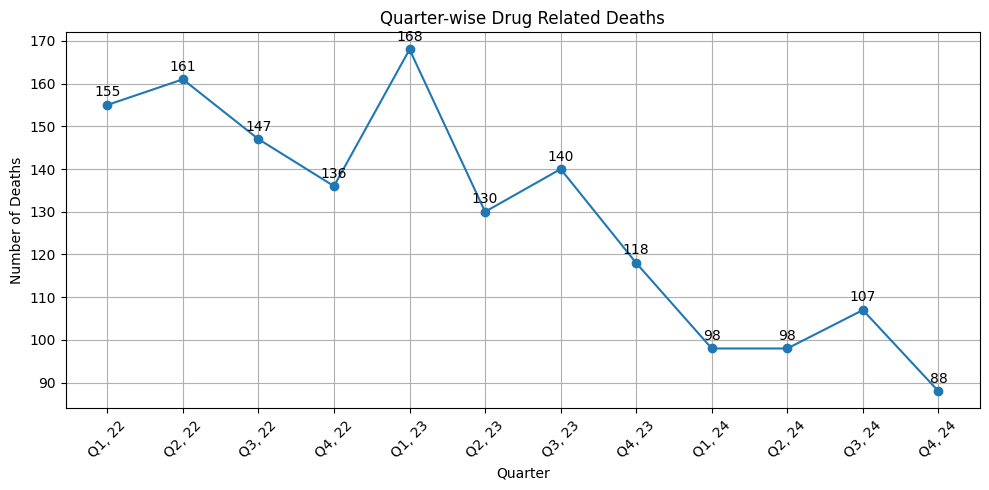

In [23]:
# Create quarter column first if not already created
df['quarter'] = df['date_of_death'].dt.to_period('Q')

quarter_dist = df['quarter'].value_counts().sort_index().reset_index()
quarter_dist.columns = ['Quarter', 'Count']

quarter_dist['Quarter_Label'] = quarter_dist['Quarter'].apply(
    lambda x: f"Q{x.quarter}, {str(x.year)[-2:]}"
)

plt.figure(figsize=(10,5))
plt.plot(quarter_dist['Quarter_Label'], quarter_dist['Count'], marker='o')

plt.title('Quarter-wise Drug Related Deaths')
plt.xlabel('Quarter')
plt.ylabel('Number of Deaths')

plt.xticks(rotation=45)
plt.grid(True)

for x, y in zip(quarter_dist['Quarter_Label'], quarter_dist['Count']):
    plt.text(x, y + 2, str(y), ha='center')

plt.tight_layout()
plt.show()

### 2. AGE GROUP DISTRIBUTION

In [25]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 20, 30, 40, 50, 60, 70, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+']
)

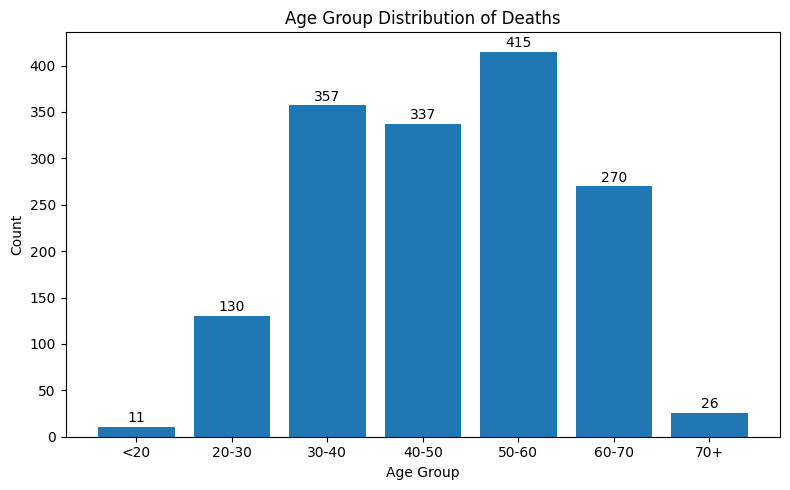

In [26]:
age_dist = df['age_group'].value_counts().sort_index().reset_index()
age_dist.columns = ['Age Group', 'Count']

plt.figure(figsize=(8,5))
bars = plt.bar(age_dist['Age Group'], age_dist['Count'])

plt.title('Age Group Distribution of Deaths')
plt.xlabel('Age Group')
plt.ylabel('Count')

# add values on bars
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5, int(y), ha='center')

plt.tight_layout()
plt.show()

### 3. SEX DISTRIBUTION

In [31]:
df['sex'] = df['sex'].astype(str).str.strip().str.title()

# Replace invalid values
df['sex'] = df['sex'].replace(['Nan', 'None', ''], 'Unknown')

In [32]:
df = df[df['sex'] != 'Unknown']

In [33]:
sex_dist = df['sex'].value_counts().sort_values(ascending=False)

colors = ['#0d3b66', '#faf0ca']  # now only Male & Female

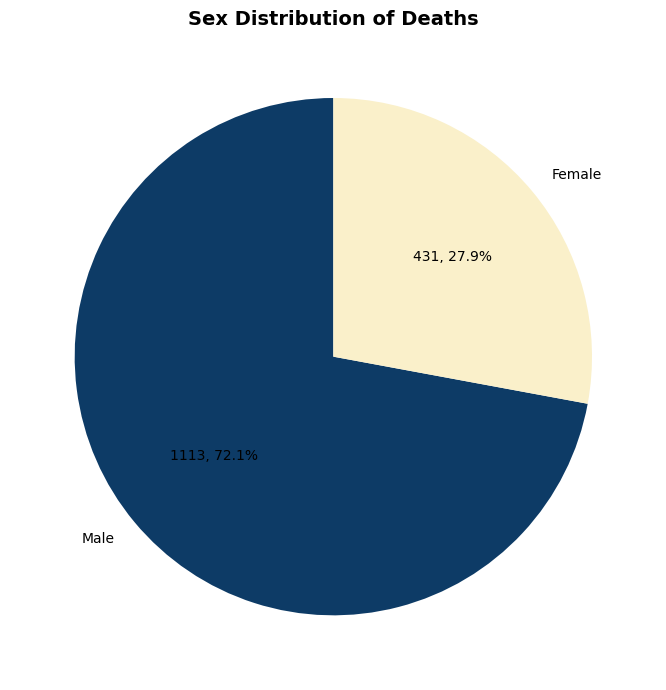

In [34]:
plt.figure(figsize=(7,7))

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{val}, {pct:.1f}%"
    return my_format

plt.pie(
    sex_dist,
    labels=sex_dist.index,
    colors=colors,
    autopct=autopct_format(sex_dist),
    startangle=90
)

plt.title('Sex Distribution of Deaths', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

### 4. RACE DISTRIBUTION

/tmp/ipykernel_2618/2461992588.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['race'] = df['race'].astype(str).str.strip().str.title()


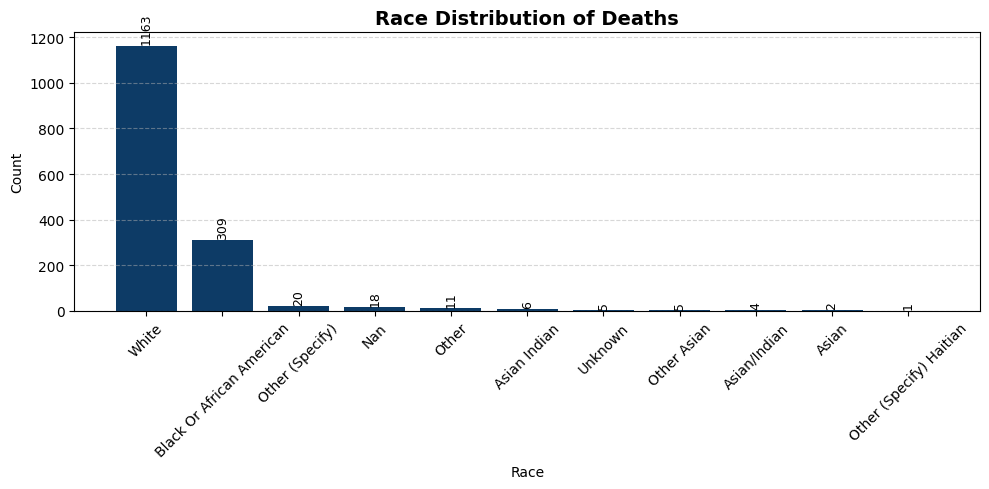

In [36]:
# Clean race column
df['race'] = df['race'].astype(str).str.strip().str.title()

# Distribution
race_dist = df['race'].value_counts().sort_values(ascending=False).reset_index()
race_dist.columns = ['Race', 'Count']

# Plot
plt.figure(figsize=(10,5))

bars = plt.bar(race_dist['Race'], race_dist['Count'], color='#0d3b66')

# Add values above bars (vertical)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,                      # slightly above bar
        f'{int(height)}',
        ha='center',
        va='bottom',
        rotation=90,                    # vertical text
        fontsize=9
    )

plt.title('Race Distribution of Deaths', fontsize=14, weight='bold')
plt.xlabel('Race')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 5. TOP DRUGS

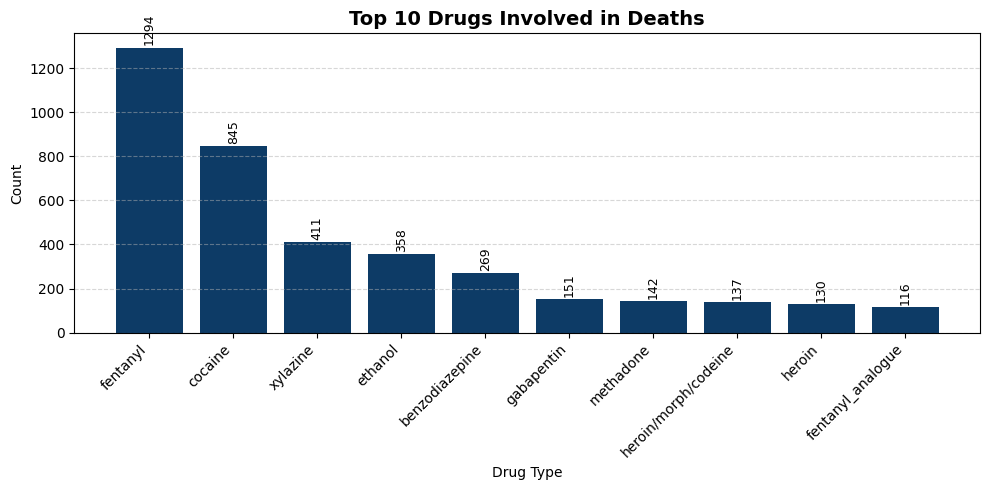

In [38]:
# Top drugs
drug_summary = df[drug_cols].sum().sort_values(ascending=False).reset_index()
drug_summary.columns = ['Drug', 'Count']

top_drugs = drug_summary.head(10)

# Plot
plt.figure(figsize=(10,5))

bars = plt.bar(top_drugs['Drug'], top_drugs['Count'], color='#0d3b66')

# Add values above bars (vertical)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10,
        f'{int(height)}',
        ha='center',
        va='bottom',
        rotation=90,
        fontsize=9
    )

# Titles & labels
plt.title('Top 10 Drugs Involved in Deaths', fontsize=14, weight='bold')
plt.xlabel('Drug Type')
plt.ylabel('Count')

# Fix overlapping labels
plt.xticks(rotation=45, ha='right')

# Add grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 6. HEATMAP

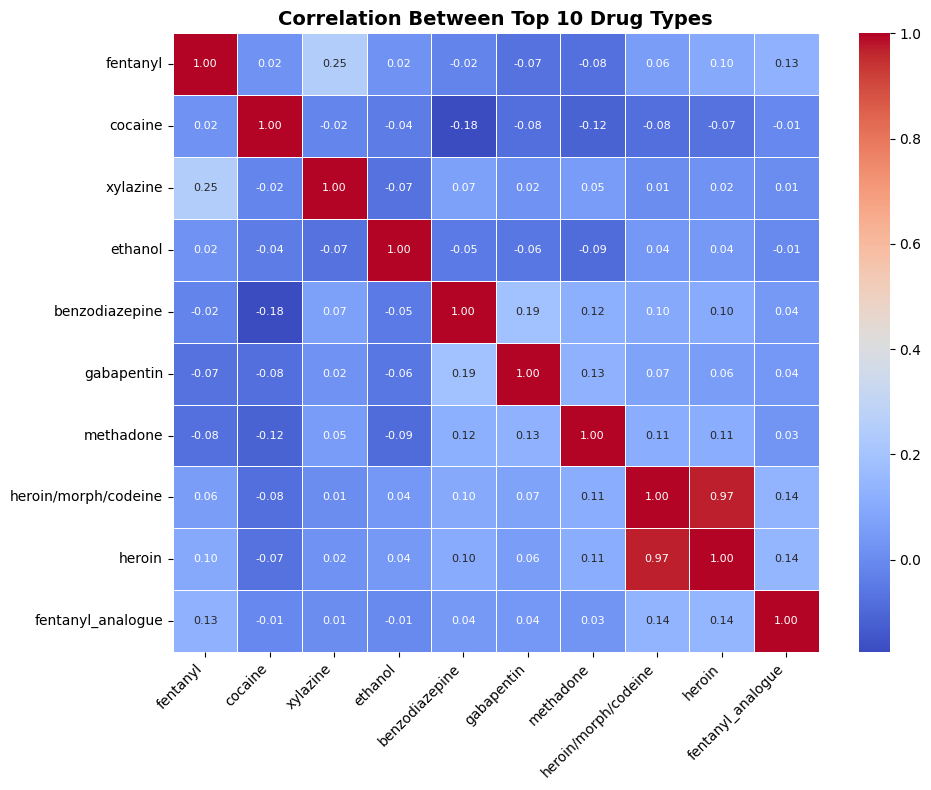

In [40]:
# Select top 10 drugs only (VERY IMPORTANT for clarity)
top_drugs_list = drug_summary['Drug'].head(10).tolist()

corr_matrix = df[top_drugs_list].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    annot_kws={"size":8},   # smaller text
    linewidths=0.5
)

plt.title('Correlation Between Top 10 Drug Types', fontsize=14, weight='bold')

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# INSIGHT GENERATION & REPORT

## 📊 Project Overview

This analysis explores accidental drug-related deaths to identify patterns across demographics, time trends, and substances involved.

The objective is to:
- Understand distribution across age, sex, and race
- Identify the most commonly involved drugs
- Analyze trends over time
- Explore relationships between different drug types

The dataset was cleaned, transformed, and analyzed using Python (Pandas, Matplotlib, Seaborn).

## 🛠 Data Preparation & Methodology

The dataset underwent the following preprocessing steps:
- Standardized column names for consistency
- Converted date fields and derived new features (Year, Month, Day, Quarter)
- Cleaned categorical variables (e.g., Sex, Race)
- Converted drug columns into binary indicators (presence/absence)
- Handled missing and inconsistent values (e.g., NaN → Unknown or excluded where necessary)

Analytical techniques used:
- GroupBy and aggregation
- Pivot tables
- Correlation analysis
- Data visualization

## 📈 Univariate Analysis Insights

### Year-wise Trend
- Drug-related deaths show a declining trend from 2022 to 2024.
- The highest number of deaths occurred in 2022.

### Age Distribution
- The majority of deaths occur in the **30–60 age group**.
- Very low cases are observed below 20 and above 70.

### Sex Distribution
- A significantly higher proportion of deaths occur among **males (~70%+)** compared to females.

### Race Distribution
- The majority of cases are concentrated among the **White population**, followed by **Black or African American**.
- Other categories contribute minimally.

## 🔍 Bivariate Analysis Insights

### Age Group vs Drug Usage
- Drugs such as **Fentanyl and Cocaine** are consistently high across all age groups.
- The **50–60 age group** shows peak involvement in multiple drugs.

### Sex vs Drug Usage
- Males dominate drug involvement across nearly all drug categories.
- Certain drugs show relatively balanced usage but still male-skewed.

### Race vs Drug Usage
- Drug-related deaths are significantly higher among the White population across most drug types.
- Distribution patterns remain consistent across major drug categories.

### Year vs Drug Trends
- Some drugs show declining trends over time, aligning with the overall reduction in deaths.

## 📊 Multivariate Analysis Insights

- Combined analysis across **Age, Sex, and Drug Types** reveals that:
  - Middle-aged males are the most affected group.
  - Multiple drug usage (poly-drug cases) is common.
- Certain drugs frequently co-occur, indicating combined substance use patterns.

## 🔗 Correlation Analysis Insights

- Most drugs show **weak to moderate positive correlations**, suggesting co-occurrence in some cases.
- Strong correlations between specific drug pairs indicate:
  - Possible combined usage patterns
  - Potential dependency relationships

- No strong negative correlations observed, meaning drugs are not mutually exclusive.

## ⭐ Key Findings

- **Fentanyl and Cocaine** are the most frequently involved drugs in deaths.
- Drug-related deaths are highest among **middle-aged individuals (30–60 years)**.
- **Males are disproportionately affected** compared to females.
- The **White population** shows the highest number of cases.
- Drug usage often involves **multiple substances simultaneously**.
- A **declining trend** in deaths is observed over recent years.

## 💡 Recommendations

- Focus prevention efforts on **high-risk groups (middle-aged males)**.
- Increase awareness and intervention programs targeting **poly-drug usage**.
- Strengthen monitoring and control of **high-impact drugs such as Fentanyl**.
- Implement community-level support in highly affected demographic groups.
- Enhance data collection to better capture emerging drug trends.

## 🧾 Conclusion

This analysis provides valuable insights into patterns of drug-related deaths, highlighting key demographic groups and substances involved.

The findings emphasize the importance of targeted intervention strategies and continuous monitoring to reduce drug-related fatalities.

Future work can include:
- Predictive modeling
- Geographic hotspot analysis
- Time-series forecasting